In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

print("Scanpy version:", sc.__version__)

Scanpy version: 1.11.5


/var/folders/m0/my66jx5974n5jwyr68bndpg80000gn/T/ipykernel_40456/2144469592.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [2]:
# PBMC 3k scRNA-seq Analysis

#Walking through a standard scRNA-seq pipeline using the 10x Genomics PBMC 3k 
#dataset — 2,700 peripheral blood mononuclear cells from a healthy donor. 

#Starting from raw counts and working through QC, normalization, clustering, 
#and cell type annotation using Scanpy. This is my first scRNA-seq analysis, 
#built as a foundation for a larger cancer genomics project.

In [3]:
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [4]:
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)
print("\nFirst 5 cell names:", adata.obs_names[:5].tolist())
print("First 5 gene names:", adata.var_names[:5].tolist())

Number of cells: 2700
Number of genes: 32738

First 5 cell names: ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
First 5 gene names: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']


In [5]:
## Quality Control

#Before any analysis, we need to filter out low quality cells. Two main 
#things to check: cells with very few detected genes are likely empty 
#droplets, and cells with high mitochondrial gene expression are likely 
#dying or damaged. Removing these prevents them from skewing the analysis.

In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(adata)

filtered out 19024 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'


In [7]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(adata.obs.head())

                  n_genes  n_genes_by_counts  total_counts  total_counts_mt  \
index                                                                         
AAACATACAACCAC-1      781                779        2419.0             73.0   
AAACATTGAGCTAC-1     1352               1352        4903.0            186.0   
AAACATTGATCAGC-1     1131               1129        3147.0             28.0   
AAACCGTGCTTCCG-1      960                960        2639.0             46.0   
AAACCGTGTATGCG-1      522                521         980.0             12.0   

                  pct_counts_mt  
index                            
AAACATACAACCAC-1       3.017776  
AAACATTGAGCTAC-1       3.793596  
AAACATTGATCAGC-1       0.889736  
AAACCGTGCTTCCG-1       1.743085  
AAACCGTGTATGCG-1       1.224490  


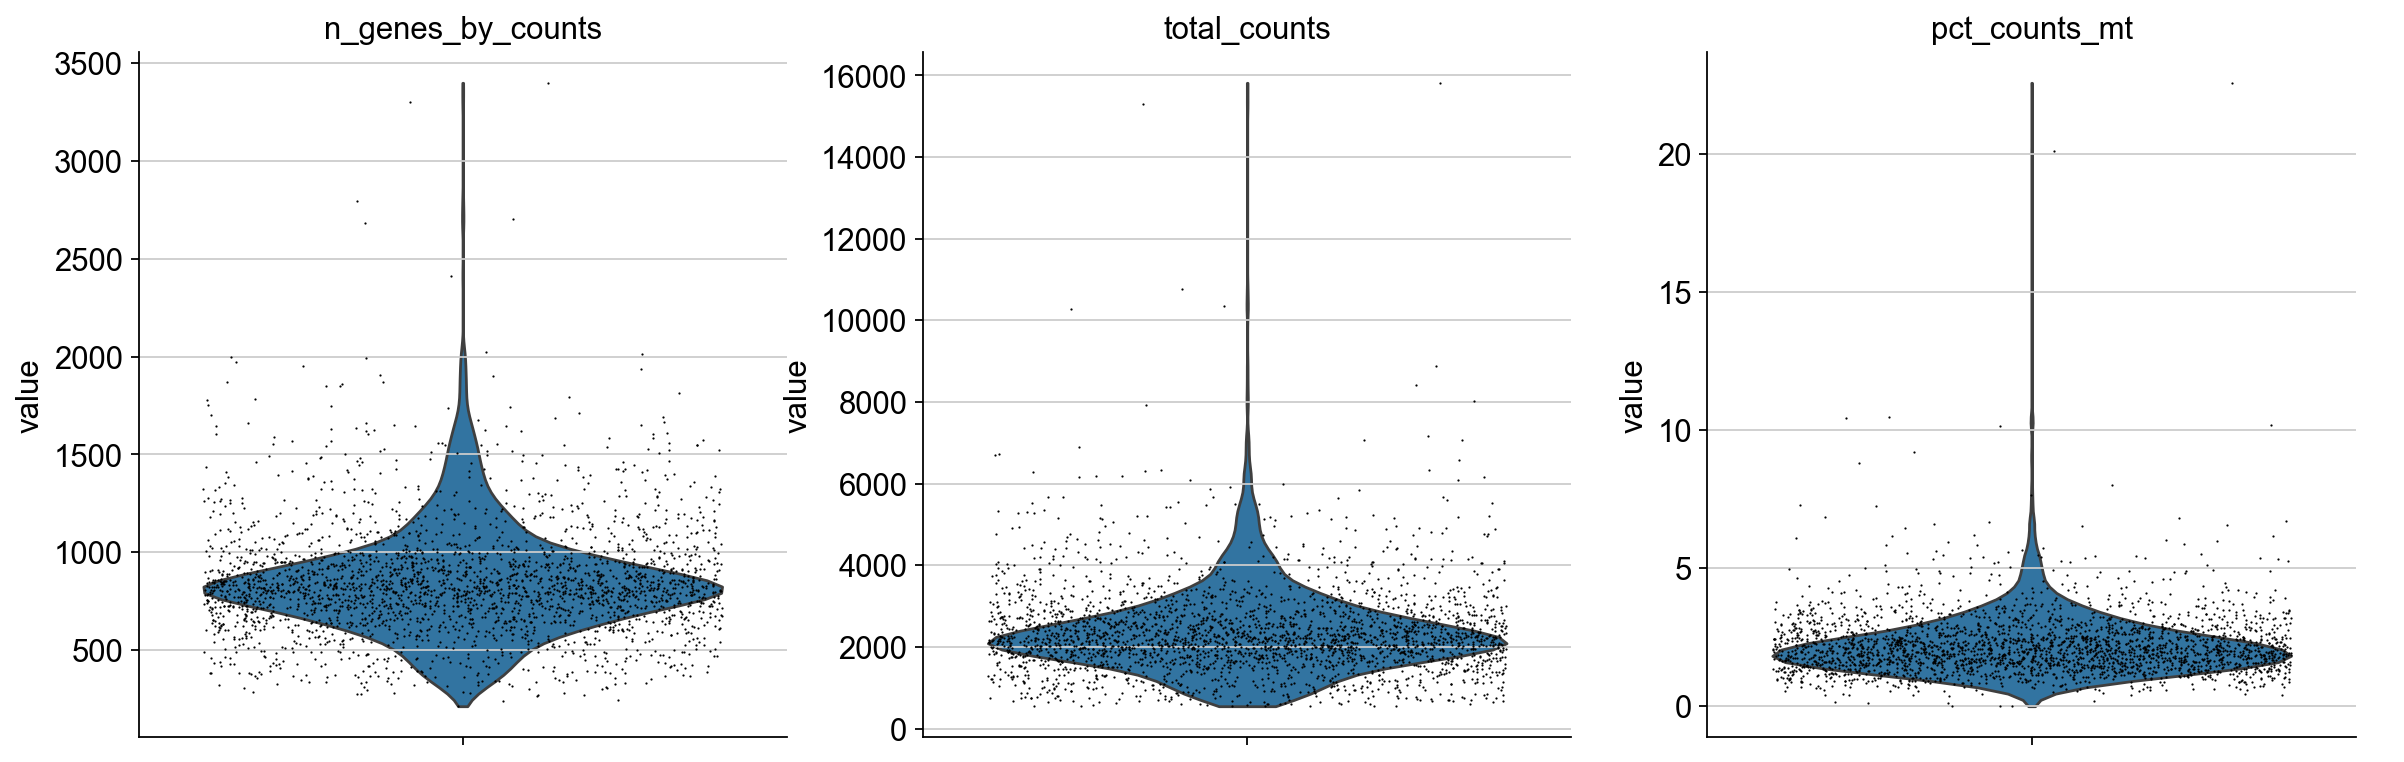

In [8]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)


In [9]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(adata)

View of AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


In [10]:
## Normalization
#Raw counts vary between cells due to sequencing depth, not biology. 
#We normalize each cell to a total count of 10,000 so cells are 
#comparable, then apply a log transformation to compress the range 
#of highly expressed genes.

In [11]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


/Users/katelyndsouza/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [12]:
## Feature Selection

#Not all 13,714 genes are informative. Genes that are expressed at 
#the same level in every cell tell us nothing about differences between 
#cell types. We select the top highly variable genes — those that vary 
#meaningfully across cells — to use for downstream analysis.

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


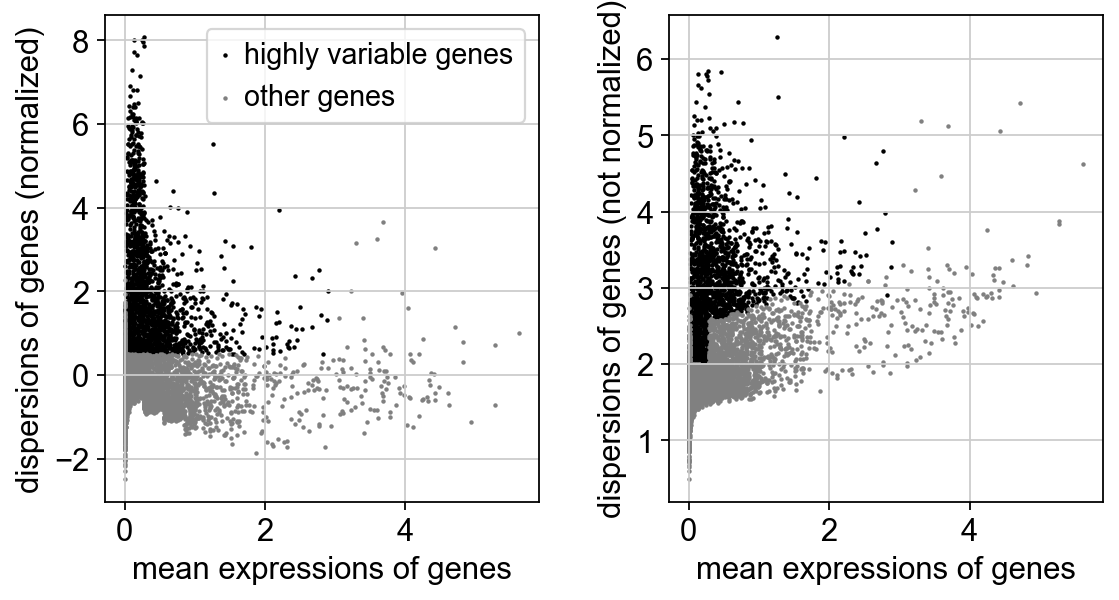

In [13]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

In [14]:
## Preprocessing

#Save the normalized counts for later, then subset to highly variable 
#genes only. We also regress out technical variation (total counts and 
#mitochondrial percentage) and scale the data so no single gene 
#dominates downstream analysis.

In [15]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
print(adata)

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'


/Users/katelyndsouza/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/katelyndsouza/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:679: RuntimeWarning: divide by zero encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)
/Users/katelyndsouza/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:679: RuntimeWarning: overflow encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)
/Users/katelyndsouza/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:679: RuntimeWarning: invalid value encountered in matmul
  coeff = inv_gram_matrix @ (regressor.T @ data)


In [16]:
## Dimensionality Reduction

#With 1,838 genes per cell, we need to reduce the dimensionality before 
#clustering. PCA compresses the gene expression data into a smaller number 
#of principal components that capture the main sources of biological variation. 
#Looking at the variance ratio plot helps us decide how many PCs to use downstream.

computing PCA
    with n_comps=50
    finished (0:00:00)


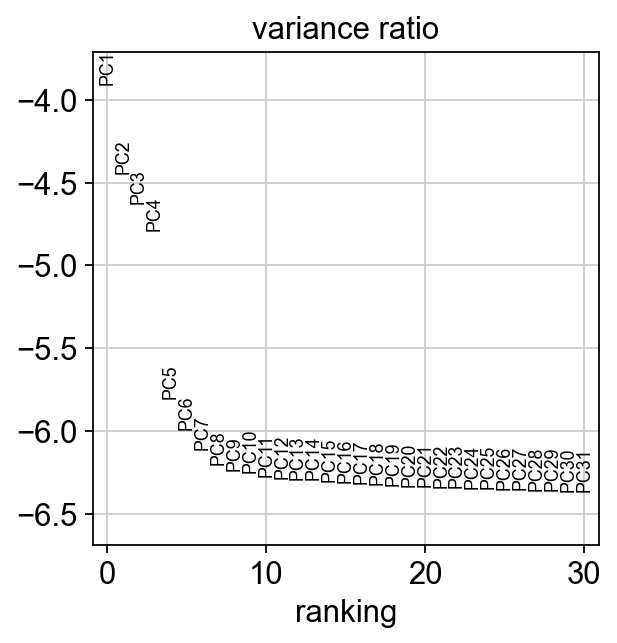

In [17]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [18]:
adata.write('data/pbmc3k_processed.h5ad')



In [19]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

adata = sc.read('data/pbmc3k_processed.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


In [20]:
## Clustering

#Using the top 10 PCs, we build a k-nearest neighbor graph connecting 
#each cell to its 10 most transcriptionally similar neighbors. The Leiden 
#algorithm then finds communities of densely connected cells — these are 
#our clusters, each representing a distinct cell population.

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.umap(adata)
sc.pl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 10


In [ ]:
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['leiden'])


In [ ]:
## Cell Type Annotation

#Cluster numbers don't mean anything biologically on their own. To figure 
#out what cell type each cluster represents, we find the marker genes — 
#genes that are uniquely and highly expressed in each cluster compared to 
#all other cells. Matching these markers against known biology lets us 
#label each cluster with a real cell type.

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

In [ ]:
cell_type_map = {
    '0': 'CD4+ T cells',
    '1': 'Monocytes',
    '2': 'B cells',
    '3': 'CD8+ T cells',
    '4': 'T cells',
    '5': 'NK/Monocytes',
    '6': 'NK cells',
    '7': 'Dendritic cells',
    '8': 'Platelets'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)
sc.pl.umap(adata, color='cell_type', legend_loc='on data', title='PBMC Cell Types')

In [ ]:
sc.pl.umap(adata, color='cell_type', legend_loc='on data', 
           title='PBMC Cell Types', save='_celltypes.png')


In [ ]:
## Summary

#Starting from 2,700 unlabeled cells, this pipeline identified 9 distinct 
#cell populations consistent with what you'd expect in healthy peripheral blood — 
#CD4+ and CD8+ T cells, B cells, NK cells, monocytes, dendritic cells, and platelets. 

#The spatial arrangement of the UMAP reflects real immune biology: T cell 
#subtypes cluster together on the left, myeloid cells group on the right, 
#and B cells sit distinctly isolated — reflecting how transcriptionally 
#different they are from everything else.

#Next step: applying this pipeline to a cancer dataset to characterize 
#tumor microenvironment cell populations.